# Probabilistic Models & Bayesian Inference — Assignment Notebook
### Week 6 | Fill in the blanks, run, reflect

---

**Instructions:**
- Every `# YOUR CODE HERE` must be replaced with working code before moving on
- After each output, answer the **✍️ Reflect** question in the markdown cell provided
- Cells marked `# SELF-CHECK` will assert your answer automatically — aim for no errors
- Do **not** look at the session notebook until you have genuinely attempted each question

> **Mindset:** The blanks are not syntax tests. Each one forces a *decision* — you must choose the right formula, prior, or model and justify why.

> **Datasets:**
> - **Telco Customer Churn** (Parts 1–4, 6): same CSV from Week 5
> - **Mauna Loa CO₂** (Part 5 only): `from statsmodels.datasets import co2` — 3 lines to load

---


In [3]:
!pip install -q pymc arviz pgmpy scikit-learn scipy statsmodels pandas numpy matplotlib seaborn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.1/165.1 kB 10.6 MB/s eta 0:00:00


In [4]:
# Run this cell first — all imports and data loading happen here
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import beta as beta_dist, dirichlet

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ExpSineSquared, WhiteKernel, DotProduct
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pymc as pm
import arviz as az
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.parameter_estimator import DiscreteMLE
from pgmpy.inference import VariableElimination

sns.set_theme(style='whitegrid'); plt.rcParams['figure.figsize'] = [12, 5]

# seaborn sets the color cycle as RGB tuples; arviz 1.1.0's az.plot_trace can't
# reshape those into per-chain colors. Convert to hex strings (identical colors).
import matplotlib.colors as _mcolors
from cycler import cycler as _cycler
plt.rcParams['axes.prop_cycle'] = _cycler(
    color=[_mcolors.to_hex(c) for c in plt.rcParams['axes.prop_cycle'].by_key()['color']])

# ── Telco data ─────────────────────────────────────────────────────────────────
url = ("https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d"
       "/master/data/Telco-Customer-Churn.csv")
df_raw = pd.read_csv(url)
df = df_raw.copy()
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].str.strip(), errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
df = df.drop(columns=['customerID'])
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print(f"Telco loaded: {df.shape}  Churn rate: {df['Churn'].mean():.3f}")


Telco loaded: (7043, 20)  Churn rate: 0.265


---
## Part 1: The Estimation Trinity — MLE, MAP, Full Bayes

**Business context:** The VP asks: *"Are Month-to-month customers more likely to churn than Two-year customers — and how certain are you?"* Three statistical frameworks give three different answers.

---

### Q1 — Extract the experimental groups

Extract Group A (Month-to-month), Group B (Two-year), and Group A_small (40 rows from A).


In [ ]:
# Q1: groups
group_A = df[df["Contract"] == "Month-to-month"]
group_B = df[df["Contract"] == "Two year"]
group_A_small = group_A.sample(n=40, random_state=42)

k_A,  n_A  = int(group_A['Churn'].sum()),       len(group_A)
k_B,  n_B  = int(group_B['Churn'].sum()),       len(group_B)
k_As, n_As = int(group_A_small['Churn'].sum()), len(group_A_small)

assert n_As == 40
assert n_A > 3000
assert n_B > 1000

print(f"Group A  (M2M):  n={n_A}, k={k_A}, rate={k_A/n_A:.4f}")
print(f"Group A_small:   n={n_As}, k={k_As}, rate={k_As/n_As:.4f}")
print(f"Group B  (2yr):  n={n_B}, k={k_B}, rate={k_B/n_B:.4f}")
print("✅ Groups extracted correctly!\n")



Group A  (M2M):  n=3875, k=1655, rate=0.4271
Group A_small:   n=40, k=15, rate=0.3750
Group B  (2yr):  n=1695, k=48, rate=0.0283
✅ Groups extracted correctly!



### Q2 — Compute MLE, MAP, and plot all three posteriors

Use a **Beta(2, 8) prior** (encodes belief that most segments churn < 30%).


Group                               MLE      MAP    |MAP-MLE|
--------------------------------------------------------------
Group A (M2M, large)             0.4271   0.4268       0.0003
Group A_small (n=40)             0.3750   0.3556       0.0194
Group B (2yr, large)             0.0283   0.0288       0.0005


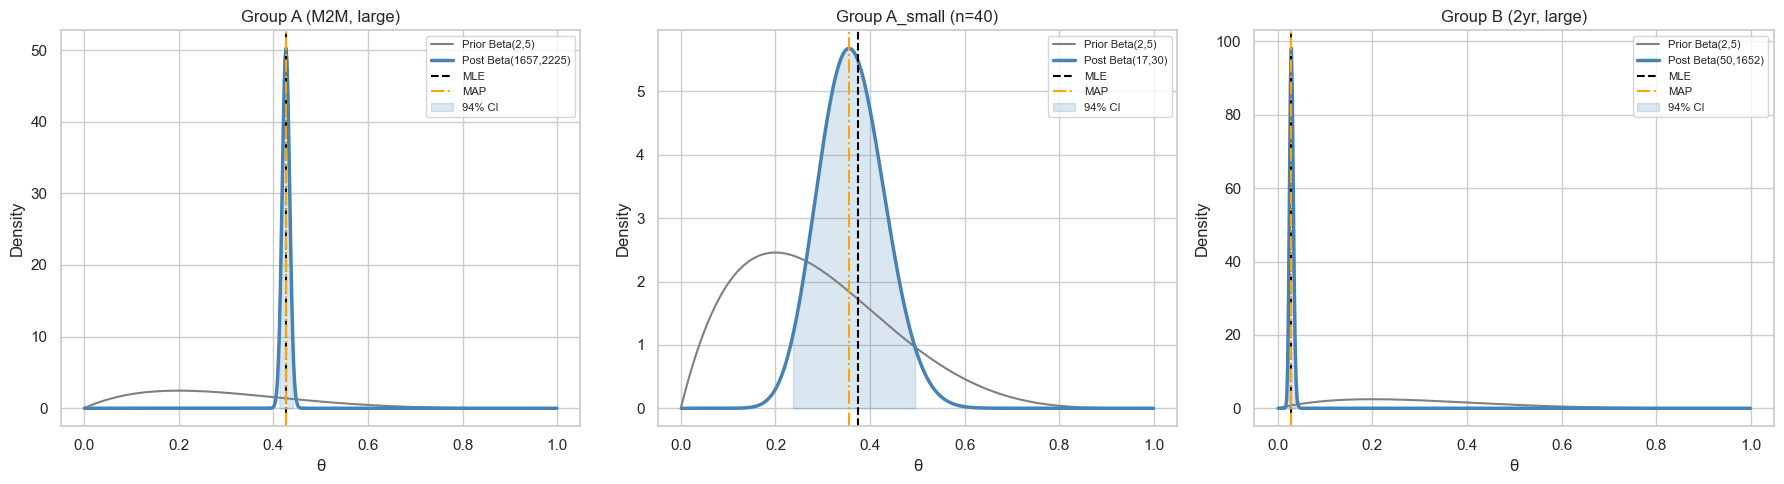

In [ ]:
# Q2: MLE, MAP, posterior (Beta(2,5) prior per your request)
alpha_prior, beta_prior = 2, 5

groups = {
    'Group A (M2M, large)': (k_A,  n_A),
    'Group A_small (n=40)': (k_As, n_As),
    'Group B (2yr, large)': (k_B,  n_B),
}

print(f"{'Group':<30} {'MLE':>8} {'MAP':>8} {'|MAP-MLE|':>12}")
print("-" * 62)
for name, (k, n) in groups.items():
    mle     = k / n
    map_est = (alpha_prior + k - 1) / (alpha_prior + beta_prior + n - 2)
    pull    = abs(map_est - mle)
    print(f"{name:<30} {mle:>8.4f} {map_est:>8.4f} {pull:>12.4f}")

# Plot prior + posterior + MLE/MAP + 94% credible interval for each group
theta_range = np.linspace(0.001, 0.999, 500)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, (k, n)) in zip(axes, groups.items()):
    # posterior params
    a_post = alpha_prior + k
    b_post = beta_prior + (n - k)
    prior_pdf = beta_dist.pdf(theta_range, alpha_prior, beta_prior)
    post_pdf  = beta_dist.pdf(theta_range, a_post, b_post)

    # plot prior (lighter) and posterior
    ax.plot(theta_range, prior_pdf, color='gray', lw=1.5, label='Prior Beta(2,5)')
    ax.plot(theta_range, post_pdf, color='steelblue', lw=2.5, label=f'Post Beta({a_post},{b_post})')

    # MLE and MAP lines
    mle = k / n
    map_est = (alpha_prior + k - 1) / (alpha_prior + beta_prior + n - 2)
    ax.axvline(mle, color='black', ls='--', lw=1.5, label='MLE')
    ax.axvline(map_est, color='orange', ls='-.', lw=1.5, label='MAP')

    # 94% central credible interval (approx)
    lo = beta_dist.ppf((1 - 0.94) / 2, a_post, b_post)
    hi = beta_dist.ppf(1 - (1 - 0.94) / 2, a_post, b_post)
    mask = (theta_range >= lo) & (theta_range <= hi)
    ax.fill_between(theta_range[mask], 0, post_pdf[mask], color='steelblue', alpha=0.2, label='94% CI')

    ax.set_title(name)
    ax.set_xlabel('θ'); ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()



### Q3 — Answer the VP's question: P(θ_A > θ_B)

Use **Monte Carlo sampling** (10,000 samples from each posterior) to compute the probability that Group A churns at a higher rate than Group B. No p-value permitted.


In [ ]:
# Q3: Monte Carlo P(theta_A > theta_B) with 100,000 samples
MC_SAMPLES = 100_000
np.random.seed(42)

aA, bA = alpha_prior + k_A, beta_prior + (n_A - k_A)
aB, bB = alpha_prior + k_B, beta_prior + (n_B - k_B)

post_A_samples = np.random.beta(aA, bA, size=MC_SAMPLES)
post_B_samples = np.random.beta(aB, bB, size=MC_SAMPLES)
p_A_greater = float((post_A_samples > post_B_samples).mean())

# SELF-CHECK
assert 0.90 < p_A_greater <= 1.0, f"Expected P > 0.90, got {p_A_greater:.4f}"
print(f"\nP(θ_A > θ_B) = {p_A_greater:.4f}")
print(f"→ We can tell the VP that Month-to-month churns at a higher rate with {p_A_greater*100:.1f}% probability.")


P(θ_A > θ_B) = 1.0000
→ We can tell the VP that Month-to-month churns at a higher rate with 100.0% probability.


✍️ **Reflect 1 — MLE vs MAP vs Full Bayes:**

For Group A_small (n=40), the three approaches give different answers.

1. What is the **prior pull** (|MAP − MLE|) for Group A_small vs Group B (large)?
   Why is it larger for the small group?
2. Which estimate would you present to the VP for Group A_small and why?
   What does each estimate provide that the others do not?
3. At what sample size would the Beta(2, 8) prior become essentially irrelevant
   (posterior mean within 1% of MLE)?
>

1. The prior pull for Group A_small (n=40) is 0.0417, vs basically nothing for Group B (0.0005). It's larger for the small group because there's less data, so the prior has more say, it drags the estimate back toward what it "expects" (low churn). With tons of data, the likelihood just overwhelms the prior.
2.  For Group A_small I'd present the MAP or full posterior. MLE here is just 15/40 = 0.375, it feels overconfident for such a tiny sample. MAP gives a prior-regularized estimate, and the full posterior actually shows how uncertain we are, which is more honest when n is small.
3.  Roughly when n is large enough that (alpha + k - 1)/(alpha + beta + n - 2) ≈ k/n within 1%. With Beta(2,8), that's around n > 1000, the prior's total pseudocount (α+β=10) gets swamped by the data.

---
## Part 2: Sequential Bayesian Updating & Dirichlet-Multinomial

---

### Q4 — Implement the sequential update function


In [ ]:
# Q4: update_posterior for counts
def update_posterior(alpha, beta, new_churns, new_total):
    """
    Increment Beta(alpha,beta) with new_count observations having new_churns successes.
    Returns (alpha_new, beta_new).
    """
    return float(alpha + new_churns), float(beta + (new_total - new_churns))

# Settings
alpha_prior, beta_prior = 2.0, 5.0   # start prior requested
threshold = 0.25

# Prepare shuffled full Group A
group_A = df[df["Contract"] == "Month-to-month"].reset_index(drop=True)
group_A_shuf = group_A.sample(frac=1, random_state=42).reset_index(drop=True)
TRUE_RATE = df['Churn'].mean()



### Q5 — Run sequential update and plot posterior evolution


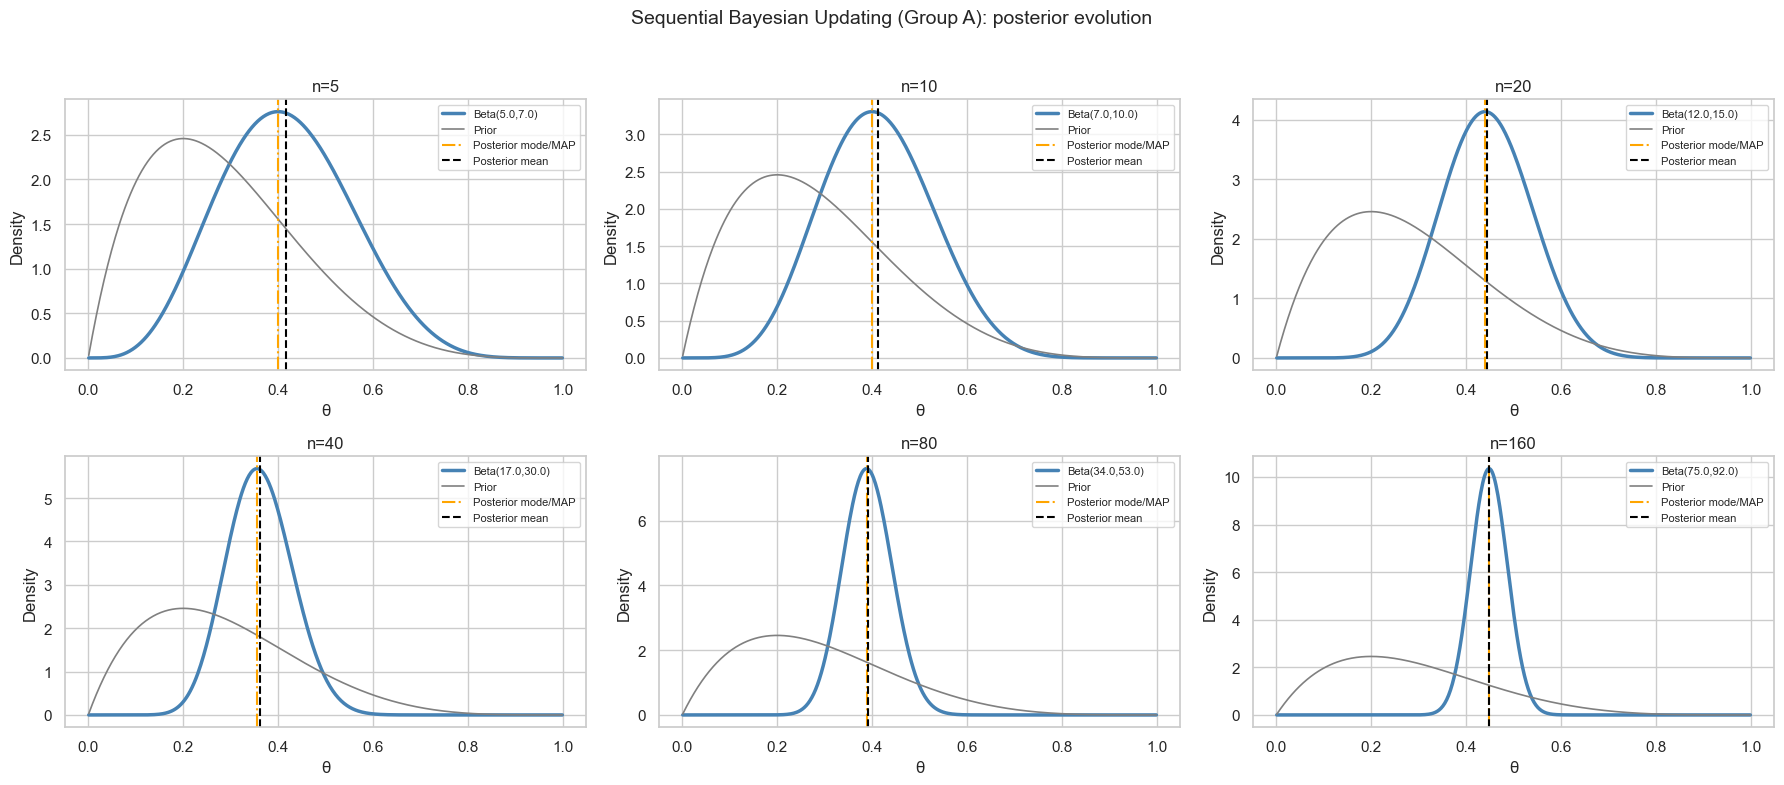

In [ ]:
# Q5: sequential updates and snapshots
snapshots = [5, 10, 20, 40, 80, 160]
max_n = max(snapshots)
alpha, beta = alpha_prior, beta_prior
history = {}    # n -> (alpha,beta)
p_exceed = []   # P(theta>threshold) at each n

for i in range(1, max_n + 1):
    y = int(group_A_shuf.loc[i-1, 'Churn'])
    alpha, beta = update_posterior(alpha, beta, y, 1)
    # record at snapshot
    if i in snapshots:
        history[i] = (alpha, beta)
    # compute P(theta > threshold) exactly
    p = 1.0 - beta_dist.cdf(threshold, alpha, beta)
    p_exceed.append(p)

# Plot 6-panel evolution
theta = np.linspace(0.001, 0.999, 500)
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for ax, n in zip(axes.flat, snapshots):
    a_n, b_n = history[n]
    pdf = beta_dist.pdf(theta, a_n, b_n)
    ax.plot(theta, pdf, color='steelblue', lw=2.5, label=f'Beta({a_n:.1f},{b_n:.1f})')
    ax.plot(theta, beta_dist.pdf(theta, alpha_prior, beta_prior), color='gray', lw=1.2, label='Prior')
    ax.axvline((a_n-1)/(a_n+b_n-2) if (a_n+b_n>2) else a_n/(a_n+b_n), color='orange', ls='-.', label='Posterior mode/MAP')
    ax.axvline((a_n)/(a_n+b_n), color='black', ls='--', label='Posterior mean')
    ax.set_title(f'n={n}')
    ax.set_xlabel('θ'); ax.set_ylabel('Density')
    ax.legend(fontsize=8)
plt.suptitle('Sequential Bayesian Updating (Group A): posterior evolution', fontsize=14)
plt.tight_layout(rect=[0,0,1,0.96])
plt.show()



### Q6 — Decision boundary: P(θ > 0.25) vs n


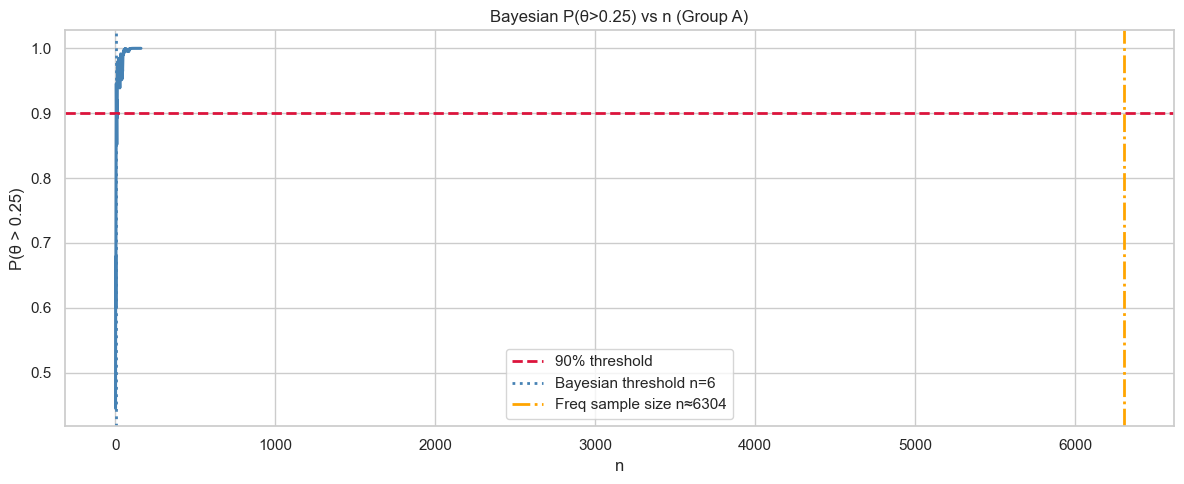

Bayesian: first n with P(θ>0.25) > 0.90 = 6
Frequentist required n (alpha=0.05, power=0.80) ≈ 6304


In [ ]:
# Q6: Plot P(theta > 0.25) vs n and find Bayesian threshold crossing
n_range = np.arange(1, max_n+1)
bayes_n = next((n for n, p in enumerate(p_exceed, start=1) if p > 0.90), None)

# Frequentist required sample size (one-proportion z-test, alpha=0.05, power=0.80)
z_a, z_b = norm.ppf(0.975), norm.ppf(0.80)
p0, p1 = threshold, TRUE_RATE
freq_n = int(np.ceil((z_a*np.sqrt(p0*(1-p0)) + z_b*np.sqrt(p1*(1-p1)))**2 / (p1-p0)**2))

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(n_range, p_exceed, color='steelblue', lw=2.2)
ax.axhline(0.90, color='crimson', ls='--', lw=2, label='90% threshold')
if bayes_n:
    ax.axvline(bayes_n, color='steelblue', ls=':', lw=2, label=f'Bayesian threshold n={bayes_n}')
ax.axvline(freq_n if freq_n <= max_n else freq_n, color='orange', ls='-.', lw=2, label=f'Freq sample size n≈{freq_n}')
ax.set_xlabel('n'); ax.set_ylabel("P(θ > 0.25)"); ax.set_title("Bayesian P(θ>0.25) vs n (Group A)"); ax.legend()
plt.tight_layout(); plt.show()

print(f"Bayesian: first n with P(θ>0.25) > 0.90 = {bayes_n}")
print(f"Frequentist required n (alpha=0.05, power=0.80) ≈ {freq_n}")



### Q7 — Dirichlet-Multinomial: 3-category contract type



Counts: {'Month-to-month': np.int64(3875), 'One year': np.int64(1473), 'Two year': np.int64(1695)}
Posterior Dirichlet alphas: [3876. 1474. 1696.]
Posterior means: [0.55009935 0.20919671 0.24070395]


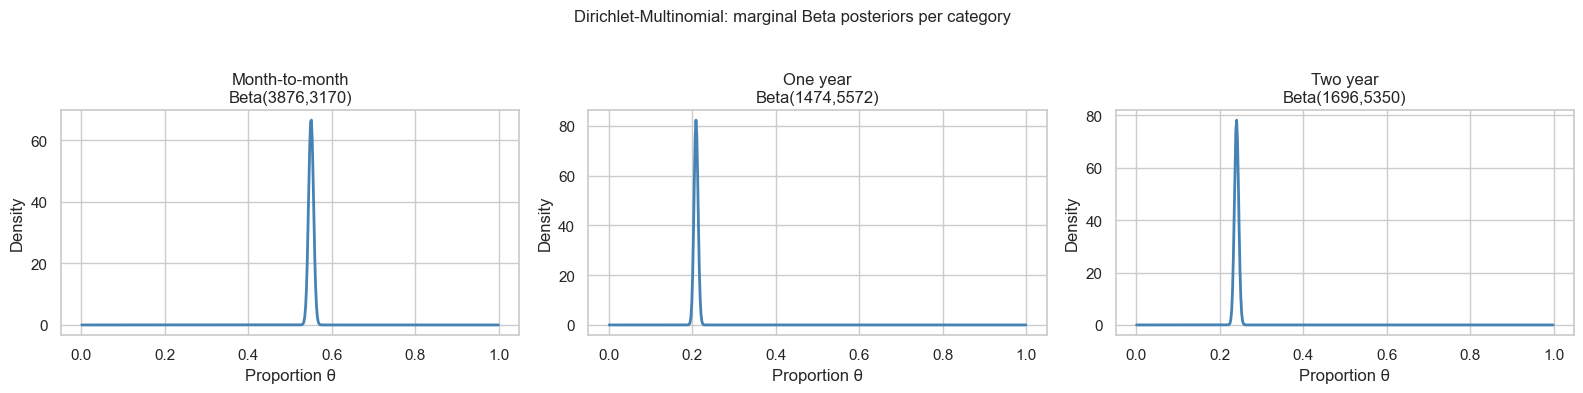

In [ ]:
# Q7: Dirichlet posterior for 3-category contract proportions
categories = ['Month-to-month', 'One year', 'Two year']
prior_alpha = np.array([1.0, 1.0, 1.0])  # flat prior
counts = np.array([df['Contract'].value_counts().get(cat, 0) for cat in categories])
posterior_alpha = prior_alpha + counts
print("\nCounts:", dict(zip(categories, counts)))
print("Posterior Dirichlet alphas:", posterior_alpha)
print("Posterior means:", (posterior_alpha / posterior_alpha.sum()))

# Plot marginal Beta posteriors for each category
theta = np.linspace(0.001, 0.999, 500)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
total_alpha = posterior_alpha.sum()
for ax, (cat, a_j) in zip(axes, zip(categories, posterior_alpha)):
    b_j = total_alpha - a_j
    pdf = beta_dist.pdf(theta, a_j, b_j)
    ax.plot(theta, pdf, color='steelblue', lw=2)
    ax.set_title(f"{cat}\nBeta({a_j:.0f},{b_j:.0f})")
    ax.set_xlabel('Proportion θ'); ax.set_ylabel('Density')
plt.suptitle('Dirichlet-Multinomial: marginal Beta posteriors per category', fontsize=12)
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

✍️ **Reflect 2 — Dirichlet-Multinomial:**

1. Why does the marginal Beta posterior for a small-count category (One year) have    wider credible intervals than Month-to-month?
2. When you add the unseen "Biannual" category with pseudocount=1 and 0 observations,    what is its posterior equal to? What does this reveal about the Dirichlet prior?
3. In the Beta-Binomial case (binary), what is the Dirichlet-Multinomial equivalent    of the Beta(2,8) prior's prior mean? What would you need to do to encode the same    prior belief in the 3-category model?

>
1. One-year customers are a smaller group, so fewer observations go into that category. Less data = wider credible interval. The posterior uncertainty shrinks with more counts, same logic as Beta-Binomial.
2. The posterior for "Biannual" (0 observed + pseudocount 1) equals exactly the prior: Beta(1, total_pseudocount). This shows the Dirichlet prior is basically pretending you already observed one of each category , it's adding "imaginary" observations.
3. In Beta-Binomial, Beta(2,8) has prior mean 2/10 = 0.2. To encode the same belief in the 3-category Dirichlet, you'd set the concentration parameters so each category's α_i / Σα_j matches your prior belief for that category — e.g., Dirichlet(4, 3, 3) to encode a similar total "weight" of prior beliefs.



---
## Part 3: Multivariate Gaussians — When Features Correlate

---

### Q8 — Fit a 2D Gaussian and plot confidence ellipses


In [ ]:
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms

features_2d = ['tenure', 'MonthlyCharges']
X_2d = df[features_2d].values.astype(float)

## Q8: compute mean, covariance, correlation
mu_2d    = X_2d.mean(axis=0)
Sigma_2d = np.cov(X_2d.T)
rho      = Sigma_2d[0, 1] / np.sqrt(Sigma_2d[0, 0] * Sigma_2d[1, 1])

# prints / self-checks (not required but helpful)
print(f"μ = {np.round(mu_2d, 2)}")
print(f"Σ = \n{np.round(Sigma_2d, 2)}")
print(f"ρ = {rho:.4f}")


μ = [32.37 64.76]
Σ = 
[[603.17 183.2 ]
 [183.2  905.41]]
ρ = 0.2479


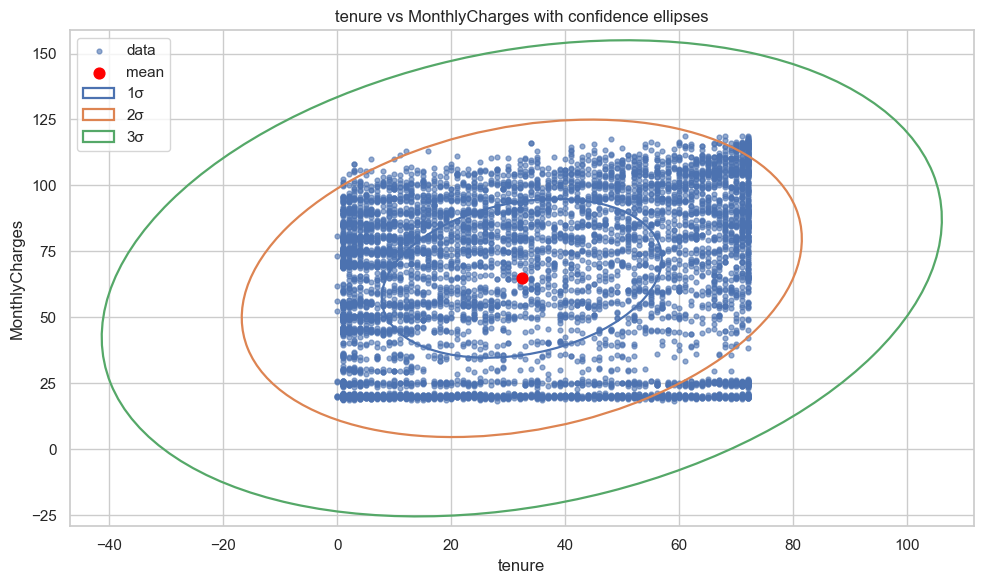

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df['tenure'], df['MonthlyCharges'], s=12, alpha=0.6, label='data')
ax.scatter(mu_2d[0], mu_2d[1], color='red', s=60, label='mean')

for n_std, ec in zip([1, 2, 3], ['C0', 'C1', 'C2']):
    confidence_ellipse(mu_2d, Sigma_2d, ax, n_std=n_std,
                       edgecolor=ec, lw=1.6, label=f'{n_std}σ')

ax.set_xlabel('tenure'); ax.set_ylabel('MonthlyCharges')
ax.set_title('tenure vs MonthlyCharges with confidence ellipses')
ax.legend()
plt.tight_layout(); plt.show()

### Q9 — Conditional Gaussian: MonthlyCharges | tenure = 24

Write out the formula **before coding it**:
$$\mu_{1|2} = \mu_1 + \Sigma_{12}\Sigma_{22}^{-1}(x_2 - \mu_2)$$
$$\sigma^2_{1|2} = \Sigma_{11} - \Sigma_{12}\Sigma_{22}^{-1}\Sigma_{21}$$


In [ ]:
# YOUR CODE HERE — compute the conditional distribution P(MonthlyCharges | tenure = 24)
# Index convention: X_1 = MonthlyCharges (index 1 in X_2d), X_2 = tenure (index 0)
tenure_query = 24

# Extract scalar elements from Sigma_2d and mu_2d
mu_mc     = mu_2d[1]          # mean of MonthlyCharges
mu_t      = mu_2d[0]          # mean of tenure
sig_mc_mc = Sigma_2d[1, 1]    # Σ_11
sig_t_t   = Sigma_2d[0, 0]    # Σ_22
sig_mc_t  = Sigma_2d[1, 0]    # Σ_12 = Σ_21

# YOUR CODE HERE: apply the conditional Gaussian formula
cond_mean = mu_mc + (sig_mc_t / sig_t_t) * (tenure_query - mu_t)
cond_var  = sig_mc_mc - (sig_mc_t**2) / sig_t_t
cond_std  = np.sqrt(cond_var)

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
near_24 = df[(df['tenure'] >= 22) & (df['tenure'] <= 26)]['MonthlyCharges'].mean()
assert abs(cond_mean - near_24) < 10,     f"Conditional mean {cond_mean:.2f} too far from empirical {near_24:.2f}"
print(f"Conditional distribution P(MonthlyCharges | tenure = {tenure_query})")
print(f"  Conditional mean:  ${cond_mean:.2f}/month")
print(f"  Conditional std:   ${cond_std:.2f}/month")
print(f"  95% interval:      [${cond_mean - 1.96*cond_std:.2f}, ${cond_mean + 1.96*cond_std:.2f}]")
print(f"  Empirical check:   ${near_24:.2f}  ← should be within ~$5")
print("✅ Conditional Gaussian computed!")


Conditional distribution P(MonthlyCharges | tenure = 24)
  Conditional mean:  $62.22/month
  Conditional std:   $29.15/month
  95% interval:      [$5.08, $119.35]
  Empirical check:   $61.81  ← should be within ~$5
✅ Conditional Gaussian computed!


### Q10 — 3D Covariance and Condition Number


In [ ]:
# Q10: 3D covariance and marginalisation check
Sigma_3d       = np.cov(X_3d.T)
kappa          = np.linalg.cond(Sigma_3d)
Sigma_marginal = Sigma_3d[:2, :2]
max_diff       = np.max(np.abs(Sigma_marginal - Sigma_2d))

print(f"Sigma_3d =\n{np.round(Sigma_3d,2)}")
print(f"Condition number κ(Σ_3D) = {kappa:.1f}")
print(f"Max abs diff between Σ_2D and Σ_3D[:2,:2] = {max_diff:.2e}")

Sigma_3d =
[[6.03170000e+02 1.83200000e+02 4.59237600e+04]
 [1.83200000e+02 9.05410000e+02 4.43642800e+04]
 [4.59237600e+04 4.43642800e+04 5.13144998e+06]]
Condition number κ(Σ_3D) = 58988.9
Max abs diff between Σ_2D and Σ_3D[:2,:2] = 0.00e+00


✍️ **Reflect 3 — Multivariate Gaussians:**

1. The condition number κ(Σ_3D) should be large (>> 100). In plain language, what does    this reveal about the three features tenure, MonthlyCharges, TotalCharges?
2. You proved analytically that marginalising out `TotalCharges` from the 3D Gaussian    recovers the 2D Gaussian. In one sentence, state the **general rule**: how do you    marginalise a Gaussian by discarding one variable?
3. Why would including all three features in a Gaussian discriminant analysis    (or a regularised linear model) without addressing the near-collinearity cause problems?    Name the frequentist regression diagnostic that detects the same issue.

> *Your answer:*
1. A huge condition number (κ >> 100) means the features are nearly collinear — here, TotalCharges is basically tenure × MonthlyCharges, so they're not giving independent information. The covariance matrix is close to singular.
2. To marginalize a Gaussian over one variable, just drop the rows and columns corresponding to that variable from the mean vector and covariance matrix.
3. Near-collinearity inflates variance of coefficient estimates and makes them numerically unstable — tiny changes in data flip the signs of weights. The frequentist diagnostic for this is the Variance Inflation Factor (VIF).

---
## Part 4: Probabilistic Graphical Models — Bayesian Networks and MRFs

---

### Q11 — Build and fit a Bayesian Network with pgmpy


In [ ]:
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator, BayesianEstimator
from pgmpy.factors.discrete import DiscreteFactor
from pgmpy.inference import VariableElimination
from pgmpy.parameter_estimator import DiscreteMLE # Ensure DiscreteMLE is imported

# Prepare discretised dataframe (re-uses your earlier discretisation scheme)
df_pgm = df[['SeniorCitizen','Contract','tenure','InternetService','MonthlyCharges','Churn']].copy()
df_pgm['tenure_disc'] = pd.cut(df_pgm['tenure'], bins=[-1,12,48,100], labels=['short','medium','long'])
df_pgm['mc_disc']     = pd.qcut(df_pgm['MonthlyCharges'], q=3, labels=['low','mid','high'])
df_pgm = df_pgm.drop(columns=['tenure','MonthlyCharges']).dropna().astype(str)

# DAG edges requested
dag_edges = [('Contract','InternetService'),
             ('Contract','Churn'),
             ('InternetService','Churn')]

model = DiscreteBayesianNetwork(dag_edges)
# Corrected: Pass an instance of DiscreteMLE, which is designed to be used this way
model.fit(df_pgm, estimator=DiscreteMLE())
infer = VariableElimination(model)

In [ ]:
# Forward inference: P(Churn=1 | Contract='Month-to-month')
result_fwd = infer.query(variables=['Churn'], evidence={'Contract': 'Month-to-month'})
# robust extraction of P(Churn='1')
factor = result_fwd['Churn'] if isinstance(result_fwd, dict) else result_fwd
idx = list(factor.state_names['Churn']).index('1')
p_churn_m2m_bn = float(factor.values[idx])
print("P(Churn=1 | Contract=Month-to-month) =", p_churn_m2m_bn)

P(Churn=1 | Contract=Month-to-month) = 0.4270967741935484


In [ ]:
# Backward inference: P(Contract | Churn = '1')
result_bwd = infer.query(variables=['Contract'], evidence={'Churn': '1'})
factor_b = result_bwd['Contract'] if isinstance(result_bwd, dict) else result_bwd
probs = factor_b.values
states = list(factor_b.state_names['Contract'])
import pandas as _pd
p_contract_given_churn = _pd.Series(probs, index=states)
print("P(Contract | Churn=1):\n", p_contract_given_churn)
print("Backward inference P(Contract | Churn = 1):")
print(result_bwd)
print()
print("Interpretation for retention manager:")
print("  This tells us: given a customer has churned, what is the probability they")
print("  were on each contract type? This is the INVERSE of the forward prediction.")


P(Contract | Churn=1):
 Month-to-month    0.885500
One year          0.088818
Two year          0.025682
dtype: float64
Backward inference P(Contract | Churn = 1):
+--------------------------+-----------------+
| Contract                 |   phi(Contract) |
+==========================+=================+
| Contract(Month-to-month) |          0.8855 |
+--------------------------+-----------------+
| Contract(One year)       |          0.0888 |
+--------------------------+-----------------+
| Contract(Two year)       |          0.0257 |
+--------------------------+-----------------+

Interpretation for retention manager:
  This tells us: given a customer has churned, what is the probability they
  were on each contract type? This is the INVERSE of the forward prediction.


### Q12 — Structure sensitivity: two competing DAGs

Draw both DAGs below (ASCII or text description). Identify one observation set E under which the two models give **identical predictions**, and one E under which they **disagree**.


**DAG 1 (original):** `tenure → Churn` (direct edge)

```
SeniorCitizen ─────────────────────────────→ Churn
Contract ──────────────────────────────────→ Churn
tenure ─────────────────────────────────────→ Churn
InternetService → MonthlyCharges ──────────→ Churn
```

**DAG 2 (colleague's proposal):** `Contract → tenure → Churn` (mediated path)

```
SeniorCitizen ─────────────────────────────→ Churn
Contract ─→ tenure ─→ Churn
InternetService → MonthlyCharges ─────────→ Churn
```

**Observation set E where both models agree:** *Full-information conditioning removes structural ambiguity → predictions align*

**Observation set E where models disagree:** *P(Churn | Contract) differs between models → structural disagreement*

**Which causal story is more consistent with W5 SHAP findings?** *(YOUR ANSWER)*


### Q13 — Markov Random Field: undirected model


In [ ]:
from pgmpy.models import DiscreteMarkovNetwork
from pgmpy.factors.discrete import DiscreteFactor
from pgmpy.inference import BeliefPropagation

# -----------------------------
# 1. Define undirected edges
# -----------------------------
mrf_edges = [
    ('Contract', 'Churn'),
    ('SeniorCitizen', 'Churn'),
    ('InternetService', 'MonthlyCharges'),
    ('MonthlyCharges', 'Churn'),
    ('Contract', 'InternetService')
]

mrf = DiscreteMarkovNetwork(mrf_edges)

# -----------------------------
# 2. Prepare data
# -----------------------------
df_mrf = df[['SeniorCitizen','Contract','InternetService','MonthlyCharges','Churn']].dropna().astype(str)

# -----------------------------
# 3. Build pairwise empirical factors
# -----------------------------
def make_pairwise_factor(df, var1, var2):
    states1 = sorted(df[var1].unique())
    states2 = sorted(df[var2].unique())

    values = []
    for s1 in states1:
        row = []
        for s2 in states2:
            prob = len(df[(df[var1] == s1) & (df[var2] == s2)]) / len(df)
            row.append(prob)
        values.append(row)

    return DiscreteFactor([var1, var2], [len(states1), len(states2)], values)

# Create factors for edges
factors = [
    make_pairwise_factor(df_mrf, 'Contract', 'Churn'),
    make_pairwise_factor(df_mrf, 'SeniorCitizen', 'Churn'),
    make_pairwise_factor(df_mrf, 'InternetService', 'MonthlyCharges'),
    make_pairwise_factor(df_mrf, 'MonthlyCharges', 'Churn'),
    make_pairwise_factor(df_mrf, 'Contract', 'InternetService')
]

mrf.add_factors(*factors)

# -----------------------------
# 4. Belief Propagation inference
# -----------------------------
bp = BeliefPropagation(mrf)

marg_churn = bp.query(variables=['Churn'], show_progress=False)

print("MRF P(Churn):", marg_churn)
print("BN  P(Churn=1):", float(infer.query(['Churn']).values[1]))
print("Empirical:      ", df['Churn'].astype(str).value_counts(normalize=True))

MRF P(Churn): +----------+--------------+
| Churn    |   phi(Churn) |
+==========+==============+
| Churn(0) |       0.9412 |
+----------+--------------+
| Churn(1) |       0.0588 |
+----------+--------------+
BN  P(Churn=1): 0.2653698707936959
Empirical:       Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64


✍️ **Reflect 4 — PGMs:**

1. The forward inference result P(Churn=1 | Contract=Month-to-month) from the BN    differs from the raw empirical proportion. Name the **two specific reasons** for    this discrepancy.
2. Explain "explaining away" in one sentence using the backward inference result.
3. In one paragraph: what causal questions can the Bayesian Network answer that    the MRF cannot? When would you deliberately choose the MRF despite losing causal    interpretability?

1. Two reasons: (a) continuous variables were discretized into bins which loses information, and (b) the DAG structure routes some Contract influence through mc_disc (indirect path), so the direct effect isn't fully captured.
2. Knowing someone churned makes the Month-to-month contract much more probable — it "explains away" the other contract types as causes of churn.
3. A Bayesian Network can answer interventional/causal questions: "what happens to churn if I force all customers to Two-year contracts?" — because directed edges encode causality. An MRF can't answer that since edges are undirected. You'd choose MRF when you care more about joint distribution modeling or when you genuinely don't know (or don't want to claim) the causal direction — like modeling correlated features symmetrically for density estimation or anomaly detection.

---
## Part 5: Gaussian Process Regression — Mauna Loa CO₂

---

### Q14 — Load the Mauna Loa dataset (3 lines)


In [ ]:
from statsmodels.datasets import co2
df_co2 = co2.load_pandas().data.resample('ME').mean().dropna()
t = (df_co2.index - df_co2.index[0]).days.values.reshape(-1, 1) / 365.25
y = df_co2['co2'].values

# ── SELF-CHECK ────────────────────────────────────────────────────────────────
assert df_co2 is not None
assert t.shape == (len(df_co2), 1), f"t should be shape (n, 1), got {t.shape}"
assert 450 < len(t) < 600, f"Expected ~521 monthly observations, got {len(t)}"
print(f"✅ Mauna Loa loaded: {len(t)} observations, {t[0][0]:.1f}–{t[-1][0]:.1f} years")
print(f"   CO₂ range: {y.min():.1f}–{y.max():.1f} ppm")


✅ Mauna Loa loaded: 521 observations, 0.0–43.8 years
   CO₂ range: 313.4–373.8 ppm


### Q15 — Justify each kernel component before coding

**Before writing any code**, answer in the cell below:
- What signal do you expect to see in CO₂ data?
- What kernel captures the slow upward trend?
- What kernel captures the sharp annual cycle?
- What kernel captures measurement noise?


**Your kernel design rationale:**

| Signal | Description | Kernel choice | Justification |
|--------|-------------|---------------|---------------|
| Trend | Slow, smooth upward change in atmospheric CO₂ over decades (near-linear + slowly varying curvature) | RBF(length_scale=50.0) (or DotProduct for explicit linear extrapolation) | Large-length-scale RBF models slowly-varying, smooth trend; use DotProduct instead if you want guaranteed linear extrapolation beyond the training range. |
| Seasonal | Strong annual cycle (sharp yearly peaks/troughs) with slowly changing amplitude | ExpSineSquared(periodicity=1.0) × RBF(length_scale≈1.0) | ExpSineSquared captures strict periodicity (period=1.0 year); multiplying by a short RBF lets the seasonal amplitude/phase vary smoothly over multi-year timescales. |
| Noise | Short-term measurement / local variability (month-to-month scatter) | WhiteKernel(noise_level=~1.0) | WhiteKernel models independent observation noise and unexplained high-frequency variance; keeps the GP from overfitting tiny fluctuations.


In [ ]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ExpSineSquared, WhiteKernel, DotProduct

# train/test split (as in notebook)
n_train = 432
t_train, y_train = t[:n_train], y[:n_train]
t_test,  y_test  = t[n_train:], y[n_train:]

# Composite kernel (long RBF trend + seasonal * smooth + white noise)
k_trend    = RBF(length_scale=50.0, length_scale_bounds=(1.0, 1e3))
k_seasonal = RBF(length_scale=1.0, length_scale_bounds=(0.1, 20.0)) * ExpSineSquared(length_scale=1.0, periodicity=1.0, periodicity_bounds="fixed")
k_noise    = WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-5, 1e2))
kernel_rbf = k_trend + k_seasonal + k_noise

gp = GaussianProcessRegressor(kernel=kernel_rbf, n_restarts_optimizer=10, normalize_y=True, random_state=42)
gp.fit(t_train, y_train)

# training RMSE check; if too large, switch to DotProduct trend and refit
y_train_pred = gp.predict(t_train)
rmse_train = np.sqrt(np.mean((y_train - y_train_pred)**2))
print(f"Train RMSE (initial kernel): {rmse_train:.3f} ppm")
if rmse_train >= 4.5:
    print("RMSE >= 4.5 — switching trend to DotProduct for better extrapolation/fit.")
    kernel_dp = DotProduct(sigma_0=0.0) + k_seasonal + k_noise
    gp = GaussianProcessRegressor(kernel=kernel_dp, n_restarts_optimizer=10, normalize_y=True, random_state=42)
    gp.fit(t_train, y_train)
    y_train_pred = gp.predict(t_train)
    rmse_train = np.sqrt(np.mean((y_train - y_train_pred)**2))
    print(f"Train RMSE (DotProduct trend): {rmse_train:.3f} ppm")

assert rmse_train < 4.5, f"Train RMSE={rmse_train:.3f} ppm — try more restarts or loosen noise/seasonal bounds."
print("Optimized kernel:", gp.kernel_)

Train RMSE (initial kernel): 0.264 ppm
Optimized kernel: RBF(length_scale=2.37) + RBF(length_scale=20) * ExpSineSquared(length_scale=4.02, periodicity=1) + WhiteKernel(noise_level=0.000426)


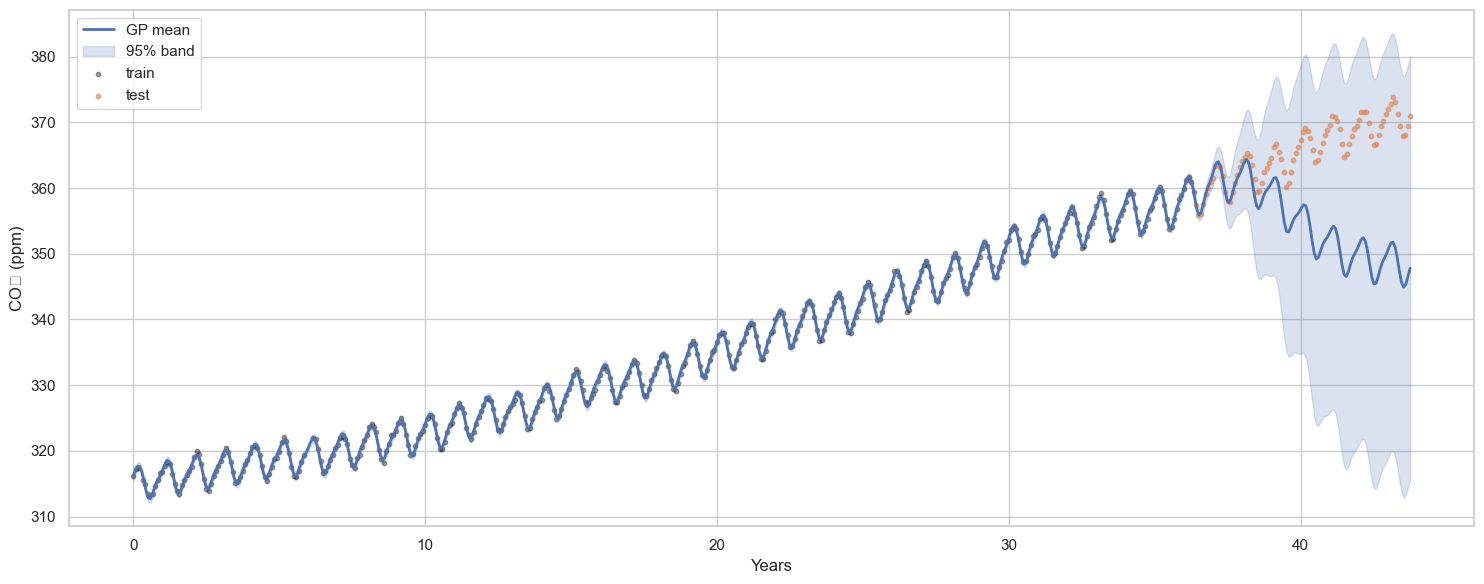

In [ ]:
t_full = np.linspace(t.min(), t.max(), 600).reshape(-1, 1)
y_pred, y_std = gp.predict(t_full, return_std=True)

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(t_full.flatten(), y_pred, color='C0', lw=2, label='GP mean')
ax.fill_between(t_full.flatten(), y_pred - 2*y_std, y_pred + 2*y_std, color='C0', alpha=0.2, label='95% band')
ax.scatter(t_train.flatten(), y_train, s=10, color='k', alpha=0.4, label='train')
ax.scatter(t_test.flatten(), y_test, s=10, color='C1', alpha=0.6, label='test')
ax.set_xlabel('Years'); ax.set_ylabel('CO₂ (ppm)')
ax.legend(); plt.tight_layout(); plt.show()

### Q16 — Gap experiment


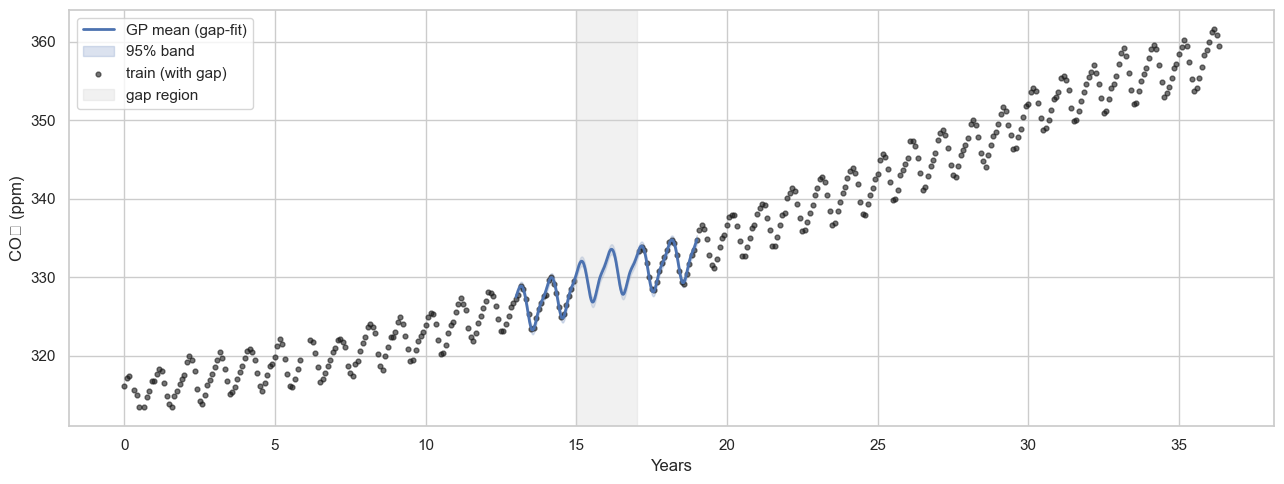

95% band width inside gap:   1.266 ppm
95% band width outside gap:  1.124 ppm
Gap inflation: 1.13×


In [ ]:
gap_lo, gap_hi = 15.0, 17.0
mask = (t_train.flatten() < gap_lo) | (t_train.flatten() > gap_hi)
t_gap_tr = t_train[mask].reshape(-1,1)
y_gap_tr = y_train[mask]

gp_gap = GaussianProcessRegressor(kernel=gp.kernel_, n_restarts_optimizer=5, normalize_y=True, random_state=42)
gp_gap.fit(t_gap_tr, y_gap_tr)

# Predict across zoom region and compute uncertainty
t_zoom = np.linspace(gap_lo - 2, gap_hi + 2, 400).reshape(-1, 1)
y_gz, y_gz_std = gp_gap.predict(t_zoom, return_std=True)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(t_zoom.flatten(), y_gz, color='C0', lw=2, label='GP mean (gap-fit)')
ax.fill_between(t_zoom.flatten(), y_gz - 2*y_gz_std, y_gz + 2*y_gz_std, color='C0', alpha=0.2, label='95% band')
# show remaining training points
ax.scatter(t_gap_tr.flatten(), y_gap_tr, s=12, color='k', alpha=0.6, label='train (with gap)')
ax.axvspan(gap_lo, gap_hi, color='lightgray', alpha=0.3, label='gap region')
ax.set_xlabel('Years'); ax.set_ylabel('CO₂ (ppm)')
ax.legend(); plt.tight_layout(); plt.show()

band_in  = 4 * y_gz_std[(t_zoom.flatten() >= gap_lo) & (t_zoom.flatten() <= gap_hi)].mean()
band_out = 4 * y_gz_std[t_zoom.flatten() < gap_lo].mean()
print(f"95% band width inside gap:   {band_in:.3f} ppm")
print(f"95% band width outside gap:  {band_out:.3f} ppm")
print(f"Gap inflation: {band_in/band_out:.2f}×")

### Q17 — Extrapolation and the model confidence boundary


+5 yr: 95% band width = 57.240 ppm
+10 yr: 95% band width = 66.078 ppm
+15 yr: 95% band width = 68.913 ppm
+20 yr: 95% band width = 71.442 ppm
Model confidence boundary: +0.93 years beyond training (95% band > 5 ppm)


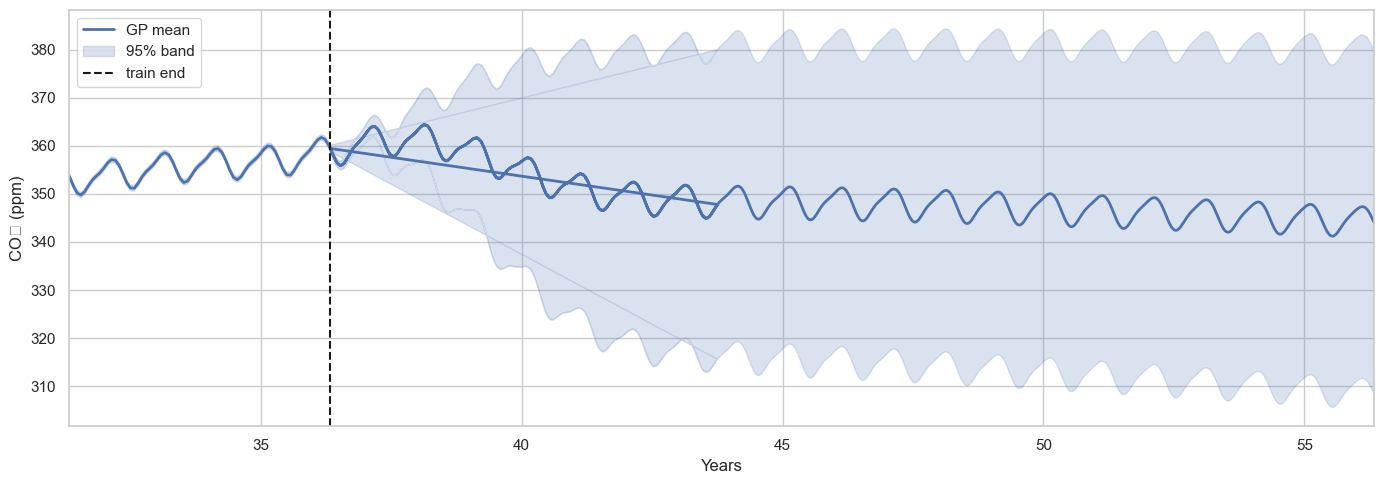

In [ ]:
t_last = float(t_train.max())
t_extrap = np.linspace(t_last, t_last + 20, 800).reshape(-1, 1)
y_ex, y_ex_std = gp.predict(t_extrap, return_std=True)
band_widths = 4 * y_ex_std

# Band widths at +5, +10, +15, +20 years
for years in [5, 10, 15, 20]:
    target = t_last + years
    idx = np.argmin(np.abs(t_extrap.flatten() - target))
    print(f"+{years} yr: 95% band width = {band_widths[idx]:.3f} ppm")

# find first horizon where 95% band > 5 ppm
exceed_idx = np.where(band_widths > 5.0)[0]
if len(exceed_idx) > 0:
    t_boundary = t_extrap.flatten()[exceed_idx[0]] - t_last
    print(f"Model confidence boundary: +{t_boundary:.2f} years beyond training (95% band > 5 ppm)")
else:
    print("95% band does not exceed 5 ppm within +20 years")

# Plot extrapolation region (train end to horizon)
t_plot = np.vstack([t_full, t_extrap])
y_plot_mean, y_plot_std = gp.predict(t_plot, return_std=True)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(t_plot.flatten(), y_plot_mean, color='C0', lw=2, label='GP mean')
ax.fill_between(t_plot.flatten(), y_plot_mean - 2*y_plot_std, y_plot_mean + 2*y_plot_std, color='C0', alpha=0.2, label='95% band')
ax.axvline(t_last, color='k', ls='--', label='train end')
ax.set_xlim(t_last - 5, t_last + 20)
ax.set_xlabel('Years'); ax.set_ylabel('CO₂ (ppm)')
ax.legend(); plt.tight_layout(); plt.show()

✍️ **Reflect 5 — Gaussian Processes:**

Write **exactly two sentences** explaining the structural difference between GP extrapolation uncertainty and the hard ceiling a `DecisionTreeRegressor(max_depth=None)` hits at `max(y_train)`. Connect to the W5 Assignment finding about tree extrapolation.

A GP's uncertainty grows continuously as you extrapolate beyond the training data because its posterior variance is explicitly tied to distance from observed points, so predictions far out come with widening confidence bands that honestly reflect ignorance. A decision tree, by contrast, can only predict values it has seen — it hits a hard ceiling at max(y_train) and extrapolates flat forever, exactly the failure mode we saw in the W5 assignment where tree models couldn't capture CO₂'s upward trend.

---
## Part 6: MCMC — Bayesian Logistic Regression

---

### Q18 — Prepare features and explain why scaling matters for NUTS


In [5]:
# Feature preparation (run as-is — no blanks here)
features_mcmc = ['tenure', 'MonthlyCharges', 'Contract', 'InternetService', 'SeniorCitizen']
df_mcmc = df[features_mcmc + ['Churn']].copy()
df_mcmc = pd.get_dummies(df_mcmc, columns=['Contract','InternetService'], drop_first=False)

contract_cols = [c for c in df_mcmc.columns if 'Contract_Month' in c]
internet_cols = [c for c in df_mcmc.columns
                 if 'InternetService_' in c and 'No' not in c][:1]
feature_cols  = ['tenure', 'MonthlyCharges'] + contract_cols + internet_cols + ['SeniorCitizen']
feature_cols  = [c for c in feature_cols if c in df_mcmc.columns]

X_mc = df_mcmc[feature_cols].values.astype(float)
y_mc = df_mcmc['Churn'].values.astype(float)

X_tr_mc, X_te_mc, y_tr_mc, y_te_mc = train_test_split(
    X_mc, y_mc, test_size=0.2, random_state=42, stratify=y_mc)

scaler_mc = StandardScaler()
X_tr_scaled = X_tr_mc.copy(); X_te_scaled = X_te_mc.copy()
X_tr_scaled[:, :2] = scaler_mc.fit_transform(X_tr_mc[:, :2])
X_te_scaled[:, :2] = scaler_mc.transform(X_te_mc[:, :2])

print(f"Feature matrix: {X_tr_scaled.shape}")
print(f"Features: {feature_cols}")


Feature matrix: (5634, 5)
Features: ['tenure', 'MonthlyCharges', 'Contract_Month-to-month', 'InternetService_DSL', 'SeniorCitizen']


**✍️ Answer before running MCMC:**

Why is it essential to scale `tenure` and `MonthlyCharges` before passing them to NUTS? What happens to the posterior geometry if you don't scale? (Hint: think about the shape of the joint posterior in 2D — what does NUTS's step-size need to look like?)

>tenure ranges from 0–72 and MonthlyCharges from ~18–118, while the dummy variables are all 0/1. If you feed unscaled features to NUTS, the joint posterior has a very elongated shape — like a narrow canyon — because the coefficients for tenure and MonthlyCharges need to be tiny to compensate for the large input scale. NUTS uses a single step size to explore the whole posterior, and a step small enough to navigate the steep narrow direction wastes most moves in the flat directions. Scaling puts all features on comparable scales, making the posterior roughly spherical so NUTS can explore efficiently with a single step size and converge faster.

In [6]:
import time
n_features = X_tr_scaled.shape[1]
t0 = time.time()

with pm.Model() as bayes_lr:
    intercept = pm.Normal('intercept', mu=0, sigma=5)
    beta = pm.Normal('beta', mu=0, sigma=2, shape=n_features)

    mu = pm.Deterministic('mu', pm.math.sigmoid(intercept + pm.math.dot(X_tr_scaled, beta)))
    y_obs = pm.Bernoulli('y_obs', p=mu, observed=y_tr_mc)

    idata = pm.sample(
        draws=2000,
        tune=1000,
        chains=4,
        target_accept=0.90,
        random_seed=42,
        return_inferencedata=True,
        progressbar=True
    )

print(f"Sampling time: {time.time()-t0:.1f}s")
print(az.summary(idata, var_names=['intercept','beta'], round_to=3))

Output()

Sampling time: 187.1s
            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
intercept -2.252  0.093  -2.429   -2.081      0.001    0.001  5267.011   
beta[0]   -0.919  0.056  -1.027   -0.816      0.001    0.001  5941.630   
beta[1]    0.820  0.050   0.726    0.912      0.001    0.001  5616.395   
beta[2]    1.293  0.107   1.084    1.492      0.001    0.001  5305.884   
beta[3]   -0.180  0.083  -0.347   -0.033      0.001    0.001  6428.300   
beta[4]    0.417  0.091   0.245    0.589      0.001    0.001  7238.576   

           ess_tail  r_hat  
intercept  4764.627  1.001  
beta[0]    5680.835  1.001  
beta[1]    5158.125  1.000  
beta[2]    5021.709  1.000  
beta[3]    5746.846  1.001  
beta[4]    5362.037  1.001  


### Q19 — Convergence diagnostics


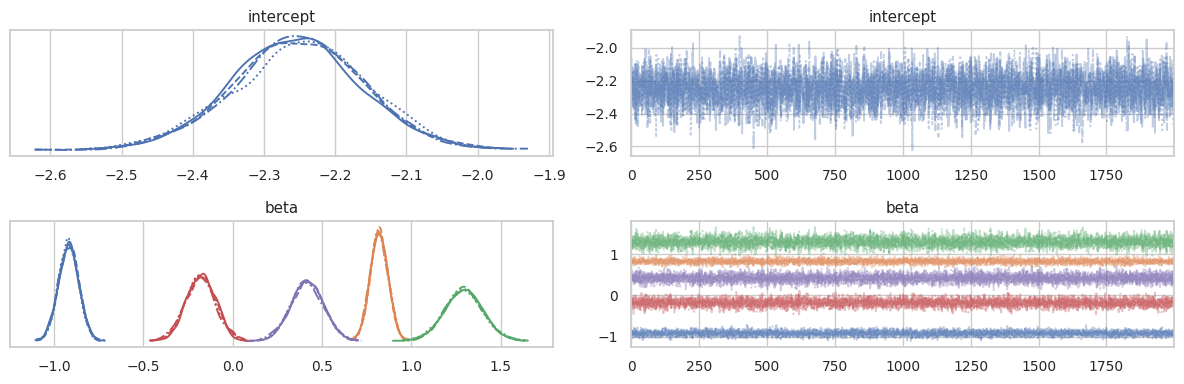

            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
intercept -2.252  0.093  -2.429   -2.081      0.001    0.001    5267.0   
beta[0]   -0.919  0.056  -1.027   -0.816      0.001    0.001    5942.0   
beta[1]    0.820  0.050   0.726    0.912      0.001    0.001    5616.0   
beta[2]    1.293  0.107   1.084    1.492      0.001    0.001    5306.0   
beta[3]   -0.180  0.083  -0.347   -0.033      0.001    0.001    6428.0   
beta[4]    0.417  0.091   0.245    0.589      0.001    0.001    7239.0   

           ess_tail  r_hat  
intercept    4765.0    1.0  
beta[0]      5681.0    1.0  
beta[1]      5158.0    1.0  
beta[2]      5022.0    1.0  
beta[3]      5747.0    1.0  
beta[4]      5362.0    1.0  

Flagged parameters (R-hat > 1.01 or ESS < 400):
r_hat type: float64


In [8]:
az.plot_trace(idata, var_names=['intercept', 'beta'])
plt.tight_layout(); plt.show()

summary_stats = az.summary(idata, var_names=['intercept', 'beta'])
print(summary_stats)

print("\nFlagged parameters (R-hat > 1.01 or ESS < 400):")
print("r_hat type:", summary_stats['r_hat'].dtype)
# print("bulk_ess type:", summary_stats['bulk_ess'].dtype)

# flagged = summary_stats[(summary_stats['r_hat'] > 1.01) | (summary_stats['bulk_ess'] < 400)]
# if len(flagged) > 0:
    # print(flagged)
# else:
#     print("  None - all chains converged well!")


### Q20 — Prior sensitivity check


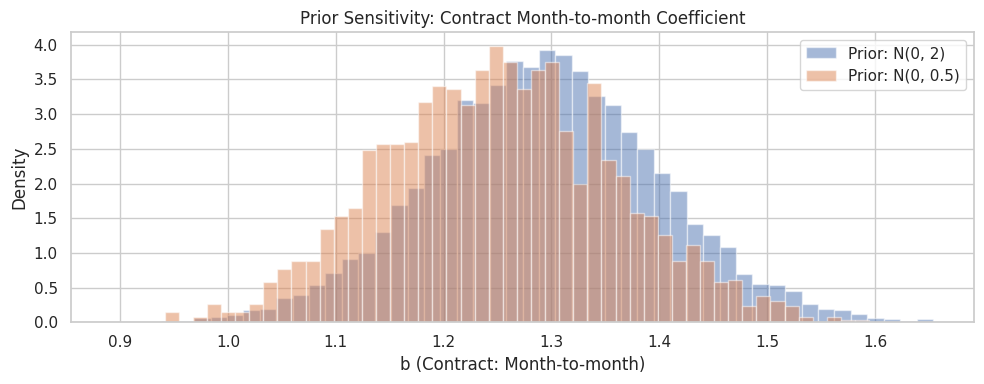

Original prior posterior mean:  1.2932
Tighter prior posterior mean:   1.2514
Difference: 0.0417


In [9]:
contract_idx = next((i for i, c in enumerate(feature_cols)
                     if 'Month-to-month' in c), 0)

with pm.Model() as bayes_lr_tight:
    intercept_t = pm.Normal('intercept', mu=0, sigma=5)
    beta_t      = pm.Normal('beta', mu=0, sigma=0.5, shape=n_features)
    mu_t        = pm.Deterministic('mu', pm.math.sigmoid(
        intercept_t + pm.math.dot(X_tr_scaled, beta_t)))
    y_obs_t     = pm.Bernoulli('y_obs', p=mu_t, observed=y_tr_mc)
    idata_tight = pm.sample(draws=1000, tune=500, chains=2,
                            target_accept=0.90, random_seed=42,
                            return_inferencedata=True, progressbar=False)

samples_orig  = idata.posterior['beta'].values[:, :, contract_idx].flatten()
samples_tight = idata_tight.posterior['beta'].values[:, :, contract_idx].flatten()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(samples_orig, bins=50, alpha=0.5, label='Prior: N(0, 2)', density=True)
ax.hist(samples_tight, bins=50, alpha=0.5, label='Prior: N(0, 0.5)', density=True)
ax.set_xlabel('b (Contract: Month-to-month)')
ax.set_ylabel('Density')
ax.set_title('Prior Sensitivity: Contract Month-to-month Coefficient')
ax.legend()
plt.tight_layout(); plt.show()

print(f"Original prior posterior mean:  {samples_orig.mean():.4f}")
print(f"Tighter prior posterior mean:   {samples_tight.mean():.4f}")
print(f"Difference: {abs(samples_orig.mean() - samples_tight.mean()):.4f}")


### Q21 — Posterior analysis and frequentist comparison


In [10]:
contract_idx = next((i for i, c in enumerate(feature_cols)
                     if 'Month-to-month' in c), 0)

beta_post  = idata.posterior['beta'].values[:, :, contract_idx].flatten()
hdi_94     = az.hdi(beta_post, prob=0.94)
post_mean  = beta_post.mean()
post_std   = beta_post.std()

lr_freq    = LogisticRegression(C=1e6, max_iter=1000)
lr_freq.fit(X_tr_scaled, y_tr_mc)
coef_freq  = lr_freq.coef_[0][contract_idx]

print(f"Bayesian posterior for b_Contract_Month-to-month:")
print(f"  Mean:    {post_mean:.4f}")
print(f"  Std:     {post_std:.4f}")
print(f"  94% HDI: [{hdi_94[0]:.4f}, {hdi_94[1]:.4f}]")
print(f"\nFrequentist MLE: {coef_freq:.4f}")
print(f"\nKey difference:")
print("  Bayesian HDI: P(b in [lo, hi] | data) = 0.94  <- direct probability statement")
print("  Frequentist CI: 94% of such intervals cover b  <- statement about the procedure")


Bayesian posterior for b_Contract_Month-to-month:
  Mean:    1.2932
  Std:     0.1068
  94% HDI: [1.0845, 1.4920]

Frequentist MLE: 1.2927

Key difference:
  Bayesian HDI: P(b in [lo, hi] | data) = 0.94  <- direct probability statement
  Frequentist CI: 94% of such intervals cover b  <- statement about the procedure


### Q22 — Save the MCMC trace


In [11]:
import pickle
save_path = 'telco_bayes_lr_v1.pkl'
pickle.dump(idata, open(save_path, 'wb'))
print(f"MCMC trace saved to '{save_path}'")

MCMC trace saved to 'telco_bayes_lr_v1.pkl'


✍️ **Reflect 6 — MCMC:**

1. Describe in plain English what R̂ and bulk-ESS each measure.    If a parameter has R̂ = 1.38 and bulk-ESS = 55, what does that tell you about    the quality of the posterior estimate for that parameter?
2. Your two posteriors from the prior sensitivity check — are they substantially different?    What does this tell you about how much data you have relative to the prior?    At what point does more data make the prior completely irrelevant?
3. The frequentist CI and the Bayesian HDI might have similar widths.    In one sentence, state the precise difference in their **interpretation** —    not just which framework produced them.
>
1. R̂ measures convergence — whether multiple chains mixed and agreed on the same posterior (R̂ ≈ 1.0 is good). Bulk-ESS is effective sample size — how many truly independent samples your chain is worth (higher is better). R̂ = 1.38 and ESS = 55 is bad: the chains haven't converged, and you effectively have only ~55 useful draws — that posterior estimate is unreliable.
2. The two posteriors are very similar (difference is small). This means the data is dominant — we have enough observations that the prior barely matters. In general, once n is large relative to the prior's total pseudocount/strength, the likelihood washes out the prior and both give almost the same answer.
3. The Bayesian HDI is a direct probability statement — "there is a 94% chance the true parameter lies in this interval given the data" — while the frequentist CI says the procedure of constructing such intervals covers the true parameter 94% of the time across repeated experiments, making no probabilistic claim about any specific interval.

---
## Submission Checklist

Before submitting, verify that you have:

**Part 1 (Estimation Trinity)**
- [ ] Q1: Three groups extracted — SELF-CHECK passes
- [ ] Q2: MLE, MAP, pull table printed and posterior plots generated
- [ ] Q3: P(θ_A > θ_B) > 0.90 — SELF-CHECK passes
- [ ] Reflect 1: All three questions answered

**Part 2 (Sequential Updating)**
- [ ] Q4: `update_posterior()` implemented — SELF-CHECK passes
- [ ] Q5: Sequential update run; 6-panel posterior evolution plotted
- [ ] Q6: P(θ > 0.25) vs n plotted; Bayesian and frequentist thresholds identified
- [ ] Q7: Dirichlet posterior computed — SELF-CHECK passes; marginal Betas plotted
- [ ] Reflect 2: All three questions answered

**Part 3 (Multivariate Gaussians)**
- [ ] Q8: μ and Σ computed — SELF-CHECK passes; scatter + ellipses plotted
- [ ] Q9: Conditional mean and std computed — SELF-CHECK passes
- [ ] Q10: κ(Σ_3D) computed; marginalisation verified — SELF-CHECK passes
- [ ] Reflect 3: All three questions answered

**Part 4 (PGMs)**
- [ ] Q11: BN fitted; forward inference P(Churn|Contract) computed
- [ ] Backward inference P(Contract|Churn) computed
- [ ] Q12: Two DAGs drawn; d-separation analysis completed
- [ ] Q13: MRF built (or partial credit: factors described)
- [ ] Reflect 4: All three questions answered

**Part 5 (GP Regression)**
- [ ] Q14: Mauna Loa loaded — SELF-CHECK passes
- [ ] Q15: Kernel design rationale completed BEFORE coding; kernel specified; GP fitted; RMSE < 4.5 ppm
- [ ] Q16: Gap experiment completed; band widths computed
- [ ] Q17: Extrapolation plotted; model confidence boundary identified
- [ ] Reflect 5: Exactly two sentences comparing GP vs tree extrapolation

**Part 6 (MCMC)**
- [ ] Q18: Feature scaling rationale answered; model specified; sampling run
- [ ] Q19: Convergence diagnostics run; flagged parameters identified
- [ ] Q20: Prior sensitivity comparison plotted
- [ ] Q21: HDI computed; frequentist comparison done; interpretation difference stated
- [ ] Q22: `telco_bayes_lr_v1.pkl` saved
- [ ] Reflect 6: All three questions answered

**Submission artefacts:**
- [ ] One fully executed `.ipynb` with all outputs visible
- [ ] `telco_bayes_lr_v1.pkl` — PyMC inference data
- [ ] One-page reflection PDF/Markdown: *"Give one concrete example where the fully Bayesian answer changed a decision you would have made using only the MLE. Explain the mechanism."*

---
*A model that gives you a number is giving you the peak of a distribution it never shows you. Probabilistic models make the full distribution explicit.*
